# Multi-Agent Systems

This notebook was created when I was studying the LangChain library based in the book **Generative AI with LangChain, Second Edition** of the authors *Bean Aufffart* and *Leonid Kuligin*. The book is based on LangChain version 0.37, but this code is based on 1.2.10.

## Preparing the API to Google's Gemini, OpenAI and others

I only have an API key for Google's Gemini, so every example will run on that model or in local model. The file that configures needs to contain the following code:

```python
import os

GOOGLE_API_KEY = "..."

def set_environment():
    variable_dict = globals().items()

    for key, value in variable_dict:
        if "API" in key or "ID" in key or "GOOGLE" in key:
            os.environ[key] = value
```

I will not upload this file to not risk of leak my own API key. The file `config.py` is listed on `.gitignore`.

So, all you need to do is to run the following code to enable all the API keys required to this notebook.

In [1]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from config import set_environment
# for the keys - as explained early in chapter 2
set_environment()

## Developing a Multi-Agent System.

In this example I will us ethe public MMLU dataset from Hugging Faces:

In [3]:
from datasets import load_dataset

ds = load_dataset("cais/mmlu", "high_school_geography")
ds_dict = ds["test"].take(100).to_dict()

print(ds_dict["question"][0])
print(ds_dict["choices"][0])

The main factor preventing subsistence economies from advancing economically is the lack of
['a currency.', 'a well-connected transportation infrastructure.', 'government activity.', 'a banking service.']


Let's configure the LLM:

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=1.0)

Now let's create a ReACT agent:

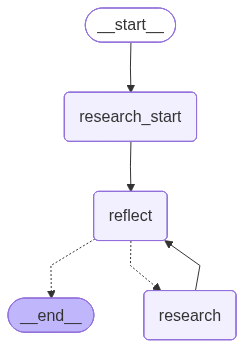

In [5]:
from langchain_core.messages import HumanMessage
from langchain_community.agent_toolkits.load_tools import load_tools
from langchain.agents import AgentState, create_agent
from langchain_core.runnables import RunnableConfig
from pydantic import Field, BaseModel
from typing import Optional, TypedDict, Annotated, Literal
from operator import add
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_core.prompts import PromptTemplate

research_tools = load_tools(
    tool_names=["ddg-search", "arxiv", "wikipedia"],
    llm = llm
)

system_prompt = (
    "You're a hard-working, curious and creative student. "
    "You're working on exam question. Think step by step."
    "Always provide an argumentation for your answer. "
    "Do not assume anything, use available tools to search "
    "for evidence and supporting statements."
)

raw_prompt_template = (
    "Answer the following multiple-choice question. "
    "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n"
)

class ResearchState(AgentState):
    question: str
    options: str

research_agent = create_agent(
    model = llm,
    tools = research_tools,
    state_schema=ResearchState,
    system_prompt=system_prompt,
)

reflection_prompt = (
    "You are a university professor and you're supervising a student who is "
    "working on multiple-choice exam question. "
    "nQUESTION: {question}.\nANSWER OPTIONS:\n{options}\n."
    "STUDENT'S ANSWER:\n{answer}\n"
    "Reflect on the answer and provide a feedback whether the answer "
    "is right or wrong. If you think the final answer is correct, reply with "
    "the final answer. Only provide critique if you think the answer might "
    "be incorrect or there are reasoning flaws. Do not assume anything, "
    "evaluate only the reasoning the student provided and whether there is "
    "enough evidence for their answer."
)

class Response(BaseModel):
    """A final response to the user."""

    answer: Optional[str] = Field(
        description="The final answer. It should be empty if critique has been provided.",
        default=None,
    )
    critique: Optional[str] = Field(
        description="A critique of the initial answer. If you think it might be incorrect, provide an actionable feedback",
        default=None,
    )

raw_prompt_template_with_critique = (
    "You tried to answer the exam question and you get feedback from your "
    "professor. Work on improving your answer and incorporating the feedback. "
    "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n\n"
    "INITIAL ANSWER:\n{answer}\n\nFEEDBACK:\n{feedback}"
)

class ReflectionState(ResearchState):
    answer: str
    feedback: str


research_agent_with_critique = create_agent(
    model = llm,
    tools = research_tools,
    state_schema=ReflectionState,
    system_prompt=system_prompt,
)

class ReflectionAgentState(TypedDict):
    question: str
    options: str
    answer: str
    steps: Annotated[int, add]
    response: Response

def _should_end(state: AgentState, config: RunnableConfig) -> Literal["research", END]:
    max_reasoning_steps = config["configurable"].get("max_reasoning_steps", 10)


    print(max_reasoning_steps)
    print(state.get("steps", 1))
    if state.get("response") and state["response"].answer:
        return END

    if state.get("steps", 1) > max_reasoning_steps:
        return END

    return "research"

reflection_chain = PromptTemplate.from_template(reflection_prompt) | llm.with_structured_output(Response)

def _reflection_step(state):
    result = reflection_chain.invoke(state)
    return {"response": result, "steps": 1}

def _research_start(state):
    formatted_content = raw_prompt_template.format(**state)
    user_message = HumanMessage(content=formatted_content)
    agent_input_state = {
        **state,
        "messages": state.get("messages", []) + [user_message],
    }
    answer = research_agent.invoke(agent_input_state)

    return {
        "answer": answer["messages"][-1].content,
    }

def _research(state):
    formatted_content = raw_prompt_template_with_critique.format(
        question=state["question"],
        options=state["options"],
        answer=state["answer"],
        feedback=state["response"].critique
    )
    user_message = HumanMessage(content=formatted_content)
    agent_input_state = {
        "messages": state.get("messages", []) + [user_message]
    }
    answer = research_agent_with_critique.invoke(agent_input_state)

    return {
        "answer": answer["messages"][-1].content,
    }

builder = StateGraph(ReflectionAgentState)

builder.add_node("research_start", _research_start)
builder.add_node("research", _research)
builder.add_node("reflect", _reflection_step)

builder.add_edge(START, "research_start")
builder.add_edge("research_start", "reflect")
builder.add_edge("research", "reflect")
builder.add_conditional_edges("reflect", _should_end, {"research": "research", END: END})

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

Now, let's test the agent (it's not working good):


In [ ]:

i = 2
question = ds_dict["question"][i]
options = "\n".join([f"{i}. {a}" for i, a in enumerate(ds_dict["choices"][i])])

print(question)
print(options)

async for _, event in graph.astream({"question": question, "options": options}, stream_mode=["updates"]):
         print(event)



## Shared Message communication

Now we will create the same solution but in a different way.

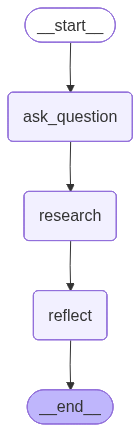

In [6]:
from langgraph.graph import MessagesState
from langgraph.types import Command

system_prompt = (
    "You're a hard-working, curious and creative student. "
    "You're working on exam question. Think step by step."
    "Always provide an argumentation for your answer. "
    "Do not assume anything, use available tools to search "
    "for evidence and supporting statements."
)

research_agent = create_agent(
    model = llm,
    tools = research_tools,
    system_prompt=system_prompt,
)

reflection_prompt = (
    "You are a university professor and you're supervising a student who is "
    "working on multiple-choice exam question. "
    "Given the dialogue above, reflect on the answer provided and give a feedback "
    " if needed. If you think the final answer is correct, reply with "
    "an empty message. Only provide critique if you think the last answer might "
    "be incorrect or there are reasoning flaws. Do not assume anything, "
    "evaluate only the reasoning the student provided and whether there is "
    "enough evidence for their answer."
)

question_template = PromptTemplate.from_template(
    "QUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n\n"
)

def _ask_question(state):
  return {"messages": [("human", question_template.invoke(state).text)]}

def _give_feedback(state, config: RunnableConfig):
  messages = state["messages"] + [("human", reflection_prompt)]
  max_messages = config["configurable"].get("max_messages", 10)

  if len(messages) > max_messages:
    return Command(
      update={},
      goto=END
    )

  result = llm.invoke(messages)

  if result.content:
    return Command(
      update={"messages": [
          ("assistant", result.content),
           ("human", "Please, address the feedback above and give an answer.")]},
      goto="research"
  )
  return Command(
      update={},
      goto=END
  )

class ReflectionAgentState(MessagesState):
  question: str
  options: str

builder = StateGraph(ReflectionAgentState)
builder.add_node("ask_question", _ask_question)
builder.add_node("research", research_agent)
builder.add_node("reflect", _give_feedback)

builder.add_edge(START, "ask_question")
builder.add_edge("ask_question", "research")
builder.add_edge("research", "reflect")
graph = builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Reasoning Paths